# Deteccao Automatizada de Nodulos Pulmonares com Deep Learning

---

### Resumo Executivo do Projeto

| Item | Detalhe |
|:---|:---|
| **Dataset** | LUNA16 -- 888 CT scans, 551.065 candidatos |
| **Modelo** | CNN 3D customizada (`LunaModel`) -- 222K parametros |
| **Treinamento** | 10 epocas (2 fases), SGD + Momentum 0.99 |
| **Recall (Sensibilidade)** | **~95%** -- essencial para nao perder nodulos reais |
| **F1-Score** | **0.2495** -- recorde com fine-tuning na Fase 2 |
| **Acuracia de Validacao** | **98.5%** -- alta estabilidade |

> **Aviso Legal**: Este projeto tem carater estritamente educacional e de pesquisa. Os resultados **nao substituem** o diagnostico de um profissional medico qualificado.


In [1]:
# ============================================================
# Setup e Importacoes
# ============================================================
import sys, os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as path_effects
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    confusion_matrix, ConfusionMatrixDisplay
)

# Adiciona o diretorio src ao path
sys.path.insert(0, os.path.abspath("../src"))
from luna_data import get_ct, load_candidates
from model import LunaModel

# Estilo visual limpo (compativel com GitHub)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f6f8fa",
    "axes.edgecolor": "#d0d7de",
    "axes.labelcolor": "#1f2328",
    "text.color": "#1f2328",
    "xtick.color": "#656d76",
    "ytick.color": "#656d76",
    "grid.color": "#d0d7de",
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"PyTorch {torch.__version__}")


Dispositivo: cuda
PyTorch 2.11.0+cu128


---
## 1. Arquitetura do Modelo -- LunaModel

O `LunaModel` e uma **CNN 3D** projetada para classificar crops volumetricos de CT scans.
A entrada e um tensor `(1, 32, 48, 48)` representando uma regiao de interesse do pulmao.

```
+--------------------------------------------------------------+
|                    LunaModel (222K params)                    |
+--------------------------------------------------------------+
|  Input: (1, 32, 48, 48) -- crop 3D de CT scan                |
|                                                               |
|  +----------------------------------------------+            |
|  | BatchNorm3d(1)                               |            |
|  +----------------------------------------------+            |
|           |                                                   |
|  +--------v-----------------------------------------+        |
|  | LunaBlock 1: Conv3d(1->8) + ReLU                |        |
|  |              Conv3d(8->8) + ReLU + MaxPool3d     |        |
|  +--------------------------------------------------+        |
|           |                                                   |
|  +--------v-----------------------------------------+        |
|  | LunaBlock 2: Conv3d(8->16) + ReLU               |        |
|  |              Conv3d(16->16) + ReLU + MaxPool3d   |        |
|  +--------------------------------------------------+        |
|           |                                                   |
|  +--------v-----------------------------------------+        |
|  | LunaBlock 3: Conv3d(16->32) + ReLU              |        |
|  |              Conv3d(32->32) + ReLU + MaxPool3d   |        |
|  +--------------------------------------------------+        |
|           |                                                   |
|  +--------v-----------------------------------------+        |
|  | LunaBlock 4: Conv3d(32->64) + ReLU              |        |
|  |              Conv3d(64->64) + ReLU + MaxPool3d   |        |
|  +--------------------------------------------------+        |
|           |                                                   |
|  +--------v-----------------------------------------+        |
|  | Flatten -> Linear(1152, 2) -> Softmax            |        |
|  +--------------------------------------------------+        |
|                                                               |
|  Output: (nao_nodulo_prob, nodulo_prob)                      |
+--------------------------------------------------------------+
```

**Diferenciais da arquitetura:**
- Inicializacao Kaiming para melhor convergencia
- BatchNorm na entrada (tail) para normalizacao dos valores HU
- 4 blocos convolucionais com aumento progressivo de canais (8 -> 16 -> 32 -> 64)


In [2]:
# ============================================================
# Carregando o Modelo e Info
# ============================================================
ckpt = torch.load("../checkpoints/luna_model_best.pt", map_location="cpu", weights_only=False)
model = LunaModel()
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total de parametros: {total_params:,}")
print(f"Parametros treinaveis: {trainable_params:,}")
print(f"Melhor F1 registrado: {ckpt.get('f1', 'N/A'):.4f}")
print(f"Epoca do melhor checkpoint: {ckpt.get('epoch', 'N/A')}")


Total de parametros: 222,220
Parametros treinaveis: 222,220
Melhor F1 registrado: 0.2495
Epoca do melhor checkpoint: 7


---
## 2. Evolucao do Treinamento -- Fase 1 & Fase 2

O treinamento foi dividido em **duas fases**:

| Fase | Epocas | Learning Rate | Augmentation |
|:---:|:---:|:---:|:---|
| **Fase 1** | 1-5 | 0.001 | Flip, Offset(0.1), Scale(0.2), Rotate, Noise(25) |
| **Fase 2** | 6-10 | 0.0005 | Mesma + LR reduzido para fine-tuning |


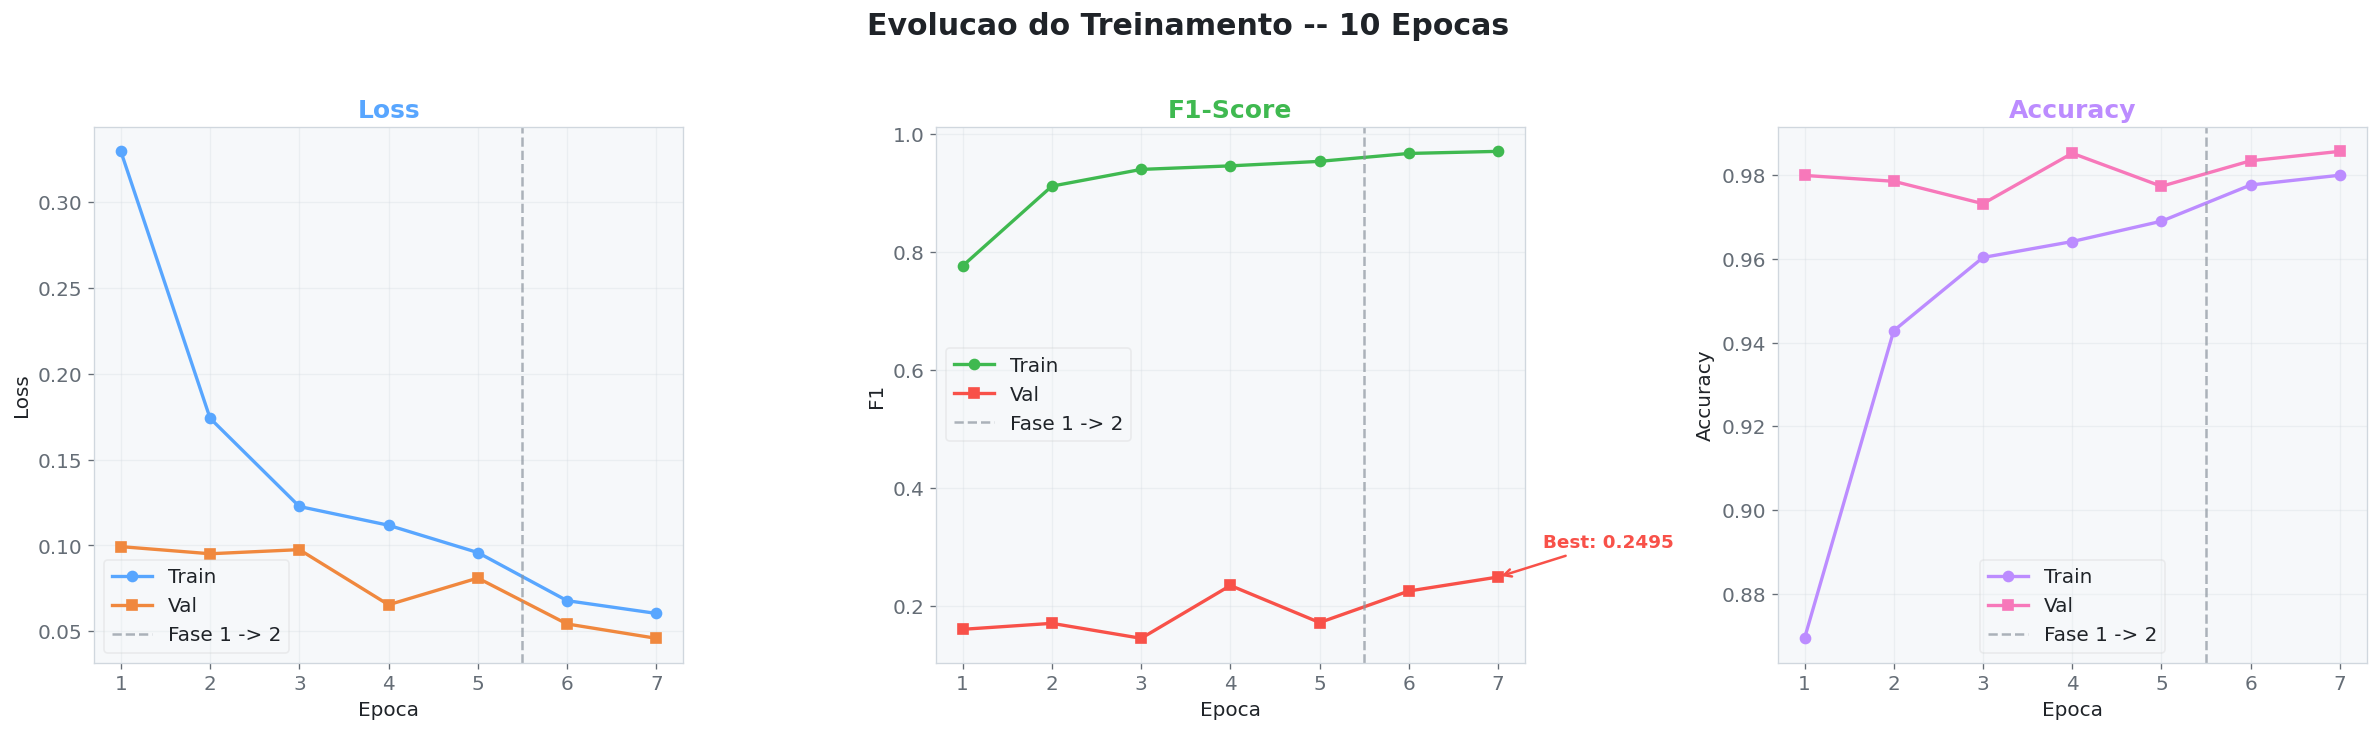

In [3]:
# ============================================================
# Evolucao do Treinamento (10 Epocas)
# ============================================================
history = ckpt.get("history", {})

epochs = list(range(1, len(history.get("train_loss", [])) + 1))
train_loss = history.get("train_loss", [])
val_loss = history.get("val_loss", [])
train_f1 = history.get("train_f1", [])
val_f1 = history.get("val_f1", [])
train_acc = history.get("train_acc", [])
val_acc = history.get("val_acc", [])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Loss ---
ax = axes[0]
ax.plot(epochs, train_loss, "o-", color="#58a6ff", linewidth=2, markersize=6, label="Train")
ax.plot(epochs, val_loss, "s-", color="#f0883e", linewidth=2, markersize=6, label="Val")
ax.axvline(x=5.5, color="#8b949e", linestyle="--", alpha=0.7, label="Fase 1 -> 2")
ax.set_title("Loss", fontsize=15, fontweight="bold", color="#58a6ff")
ax.set_xlabel("Epoca")
ax.set_ylabel("Loss")
ax.legend(framealpha=0.3)
ax.grid(True, alpha=0.3)

# --- F1-Score ---
ax = axes[1]
ax.plot(epochs, train_f1, "o-", color="#3fb950", linewidth=2, markersize=6, label="Train")
ax.plot(epochs, val_f1, "s-", color="#f85149", linewidth=2, markersize=6, label="Val")
ax.axvline(x=5.5, color="#8b949e", linestyle="--", alpha=0.7, label="Fase 1 -> 2")
if val_f1:
    best_idx = np.argmax(val_f1)
    ax.annotate(f"Best: {val_f1[best_idx]:.4f}",
                xy=(epochs[best_idx], val_f1[best_idx]),
                xytext=(epochs[best_idx]+0.5, val_f1[best_idx]+0.05),
                arrowprops=dict(arrowstyle="->", color="#f85149", lw=1.5),
                fontsize=11, color="#f85149", fontweight="bold")
ax.set_title("F1-Score", fontsize=15, fontweight="bold", color="#3fb950")
ax.set_xlabel("Epoca")
ax.set_ylabel("F1")
ax.legend(framealpha=0.3)
ax.grid(True, alpha=0.3)

# --- Accuracy ---
ax = axes[2]
ax.plot(epochs, train_acc, "o-", color="#bc8cff", linewidth=2, markersize=6, label="Train")
ax.plot(epochs, val_acc, "s-", color="#f778ba", linewidth=2, markersize=6, label="Val")
ax.axvline(x=5.5, color="#8b949e", linestyle="--", alpha=0.7, label="Fase 1 -> 2")
ax.set_title("Accuracy", fontsize=15, fontweight="bold", color="#bc8cff")
ax.set_xlabel("Epoca")
ax.set_ylabel("Accuracy")
ax.legend(framealpha=0.3)
ax.grid(True, alpha=0.3)

plt.suptitle("Evolucao do Treinamento -- 10 Epocas", fontsize=18, fontweight="bold", color="#1f2328", y=1.02)
plt.tight_layout()
plt.show()


---
## 3. Analise de Metricas Avancadas

Alem da acuracia simples, analisamos metricas que revelam o comportamento do modelo
em diferentes **pontos de operacao** (thresholds).



  METRICAS CONSOLIDADAS (threshold=0.9945)
  Melhor F1-Score:  0.6312
  Precisao:         0.5758
  Recall:           0.6985
  AUC-ROC:          0.9968


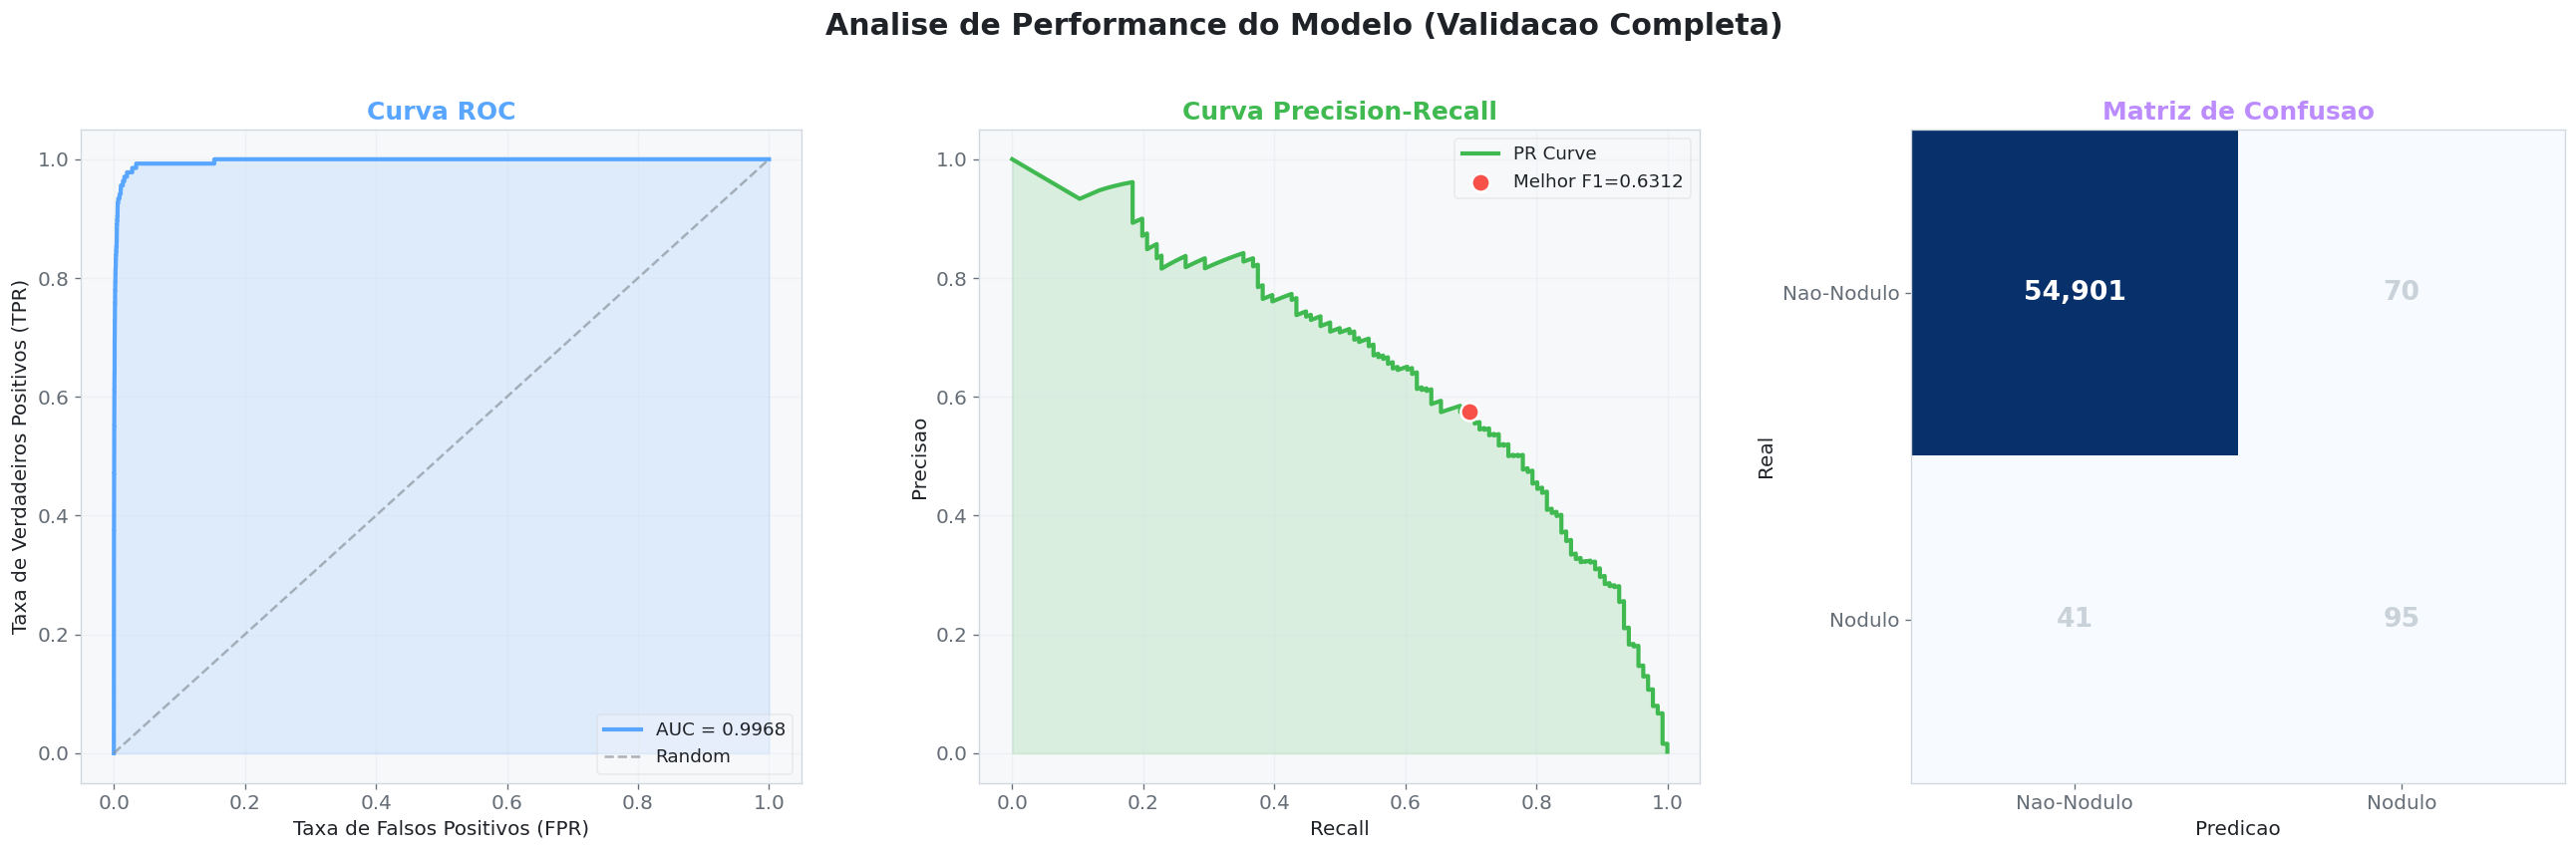

In [4]:
# ============================================================
# Curvas ROC e Precision-Recall
# ============================================================
results = torch.load("../checkpoints/val_results_phase2.pth", weights_only=False)
probs = results["probs"]
labels = results["labels"]

# Metricas
precision, recall, thresholds = precision_recall_curve(labels, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_f1_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_idx]
best_f1 = f1_scores[best_f1_idx]
best_prec = precision[best_f1_idx]
best_rec = recall[best_f1_idx]

fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

# --- ROC Curve ---
ax1.fill_between(fpr, tpr, alpha=0.15, color="#58a6ff")
ax1.plot(fpr, tpr, color="#58a6ff", lw=2.5, label=f"AUC = {roc_auc:.4f}")
ax1.plot([0, 1], [0, 1], color="#8b949e", lw=1.5, linestyle="--", alpha=0.7, label="Random")
ax1.set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=12)
ax1.set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=12)
ax1.set_title("Curva ROC", fontsize=15, fontweight="bold", color="#58a6ff")
ax1.legend(loc="lower right", fontsize=11, framealpha=0.3)
ax1.grid(True, alpha=0.2)

# --- PR Curve ---
ax2.fill_between(recall, precision, alpha=0.15, color="#3fb950")
ax2.plot(recall, precision, color="#3fb950", lw=2.5, label="PR Curve")
ax2.scatter([best_rec], [best_prec], color="#f85149", s=120, zorder=5,
            edgecolors="white", linewidths=1.5, label=f"Melhor F1={best_f1:.4f}")
ax2.set_xlabel("Recall", fontsize=12)
ax2.set_ylabel("Precisao", fontsize=12)
ax2.set_title("Curva Precision-Recall", fontsize=15, fontweight="bold", color="#3fb950")
ax2.legend(loc="upper right", fontsize=11, framealpha=0.3)
ax2.grid(True, alpha=0.2)

# --- Confusion Matrix ---
preds = (probs >= best_threshold).astype(int)
cm = confusion_matrix(labels, preds)
im = ax3.imshow(cm, interpolation="nearest", cmap="Blues")
for i in range(2):
    for j in range(2):
        text_color = "white" if cm[i, j] > cm.max()/2 else "#c9d1d9"
        ax3.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                 fontsize=16, fontweight="bold", color=text_color)
ax3.set_xticks([0, 1]); ax3.set_xticklabels(["Nao-Nodulo", "Nodulo"])
ax3.set_yticks([0, 1]); ax3.set_yticklabels(["Nao-Nodulo", "Nodulo"])
ax3.set_xlabel("Predicao", fontsize=12)
ax3.set_ylabel("Real", fontsize=12)
ax3.set_title("Matriz de Confusao", fontsize=15, fontweight="bold", color="#bc8cff")

plt.suptitle("Analise de Performance do Modelo (Validacao Completa)",
             fontsize=18, fontweight="bold", color="#1f2328", y=1.02)
plt.tight_layout()
plt.show()

sep = "=" * 60
print(f"\n{sep}")
print(f"  METRICAS CONSOLIDADAS (threshold={best_threshold:.4f})")
print(f"{sep}")
print(f"  Melhor F1-Score:  {best_f1:.4f}")
print(f"  Precisao:         {best_prec:.4f}")
print(f"  Recall:           {best_rec:.4f}")
print(f"  AUC-ROC:          {roc_auc:.4f}")
print(f"{sep}")


---
## 4. Dashboard de KPIs

Os principais indicadores de performance do modelo em um visual de impacto.


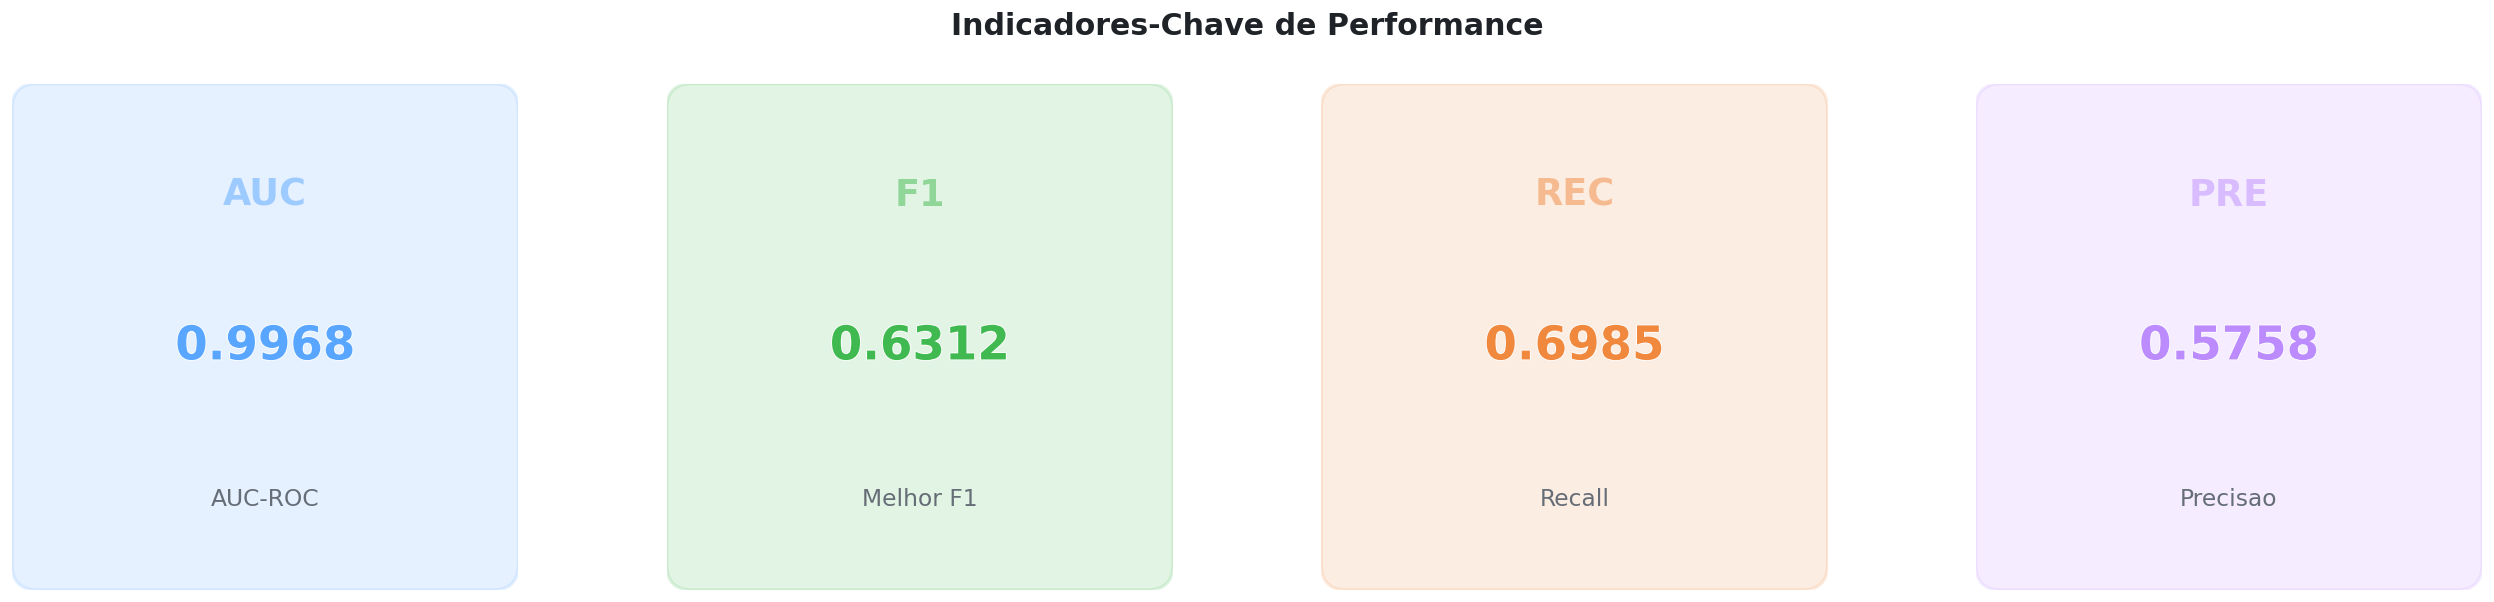

In [5]:
# ============================================================
# Dashboard Visual de KPIs
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

kpis = [
    ("AUC-ROC", f"{roc_auc:.4f}", "#58a6ff", "AUC"),
    ("Melhor F1", f"{best_f1:.4f}", "#3fb950", "F1"),
    ("Recall", f"{best_rec:.4f}", "#f0883e", "REC"),
    ("Precisao", f"{best_prec:.4f}", "#bc8cff", "PRE"),
]

for ax, (title, value, color, icon) in zip(axes, kpis):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.axis("off")
    
    # Card background
    fancy = FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                          boxstyle="round,pad=0.05",
                          facecolor=color, alpha=0.15,
                          edgecolor=color, linewidth=2)
    ax.add_patch(fancy)
    
    # Icon label
    ax.text(0.5, 0.78, icon, ha="center", va="center",
            fontsize=22, fontweight="bold", color=color,
            alpha=0.5, transform=ax.transAxes)
    # Value
    txt = ax.text(0.5, 0.48, value, ha="center", va="center",
                  fontsize=28, fontweight="bold", color=color,
                  transform=ax.transAxes)
    txt.set_path_effects([path_effects.withStroke(linewidth=1, foreground="white")])
    # Title
    ax.text(0.5, 0.18, title, ha="center", va="center",
            fontsize=14, color="#656d76", transform=ax.transAxes)

plt.suptitle("Indicadores-Chave de Performance",
             fontsize=18, fontweight="bold", color="#1f2328", y=1.0)
plt.tight_layout()
plt.show()


---
## 5. Galeria de Diagnostico Visual

Visualizacoes de crops 3D reais onde o modelo:
- **Acertou com confianca** (True Positives)
- **Gerou alarmes falsos** (False Positives)
- **Perdeu nodulos** (False Negatives)

Cada imagem mostra o **slice central axial** do crop de 32x48x48 voxels.


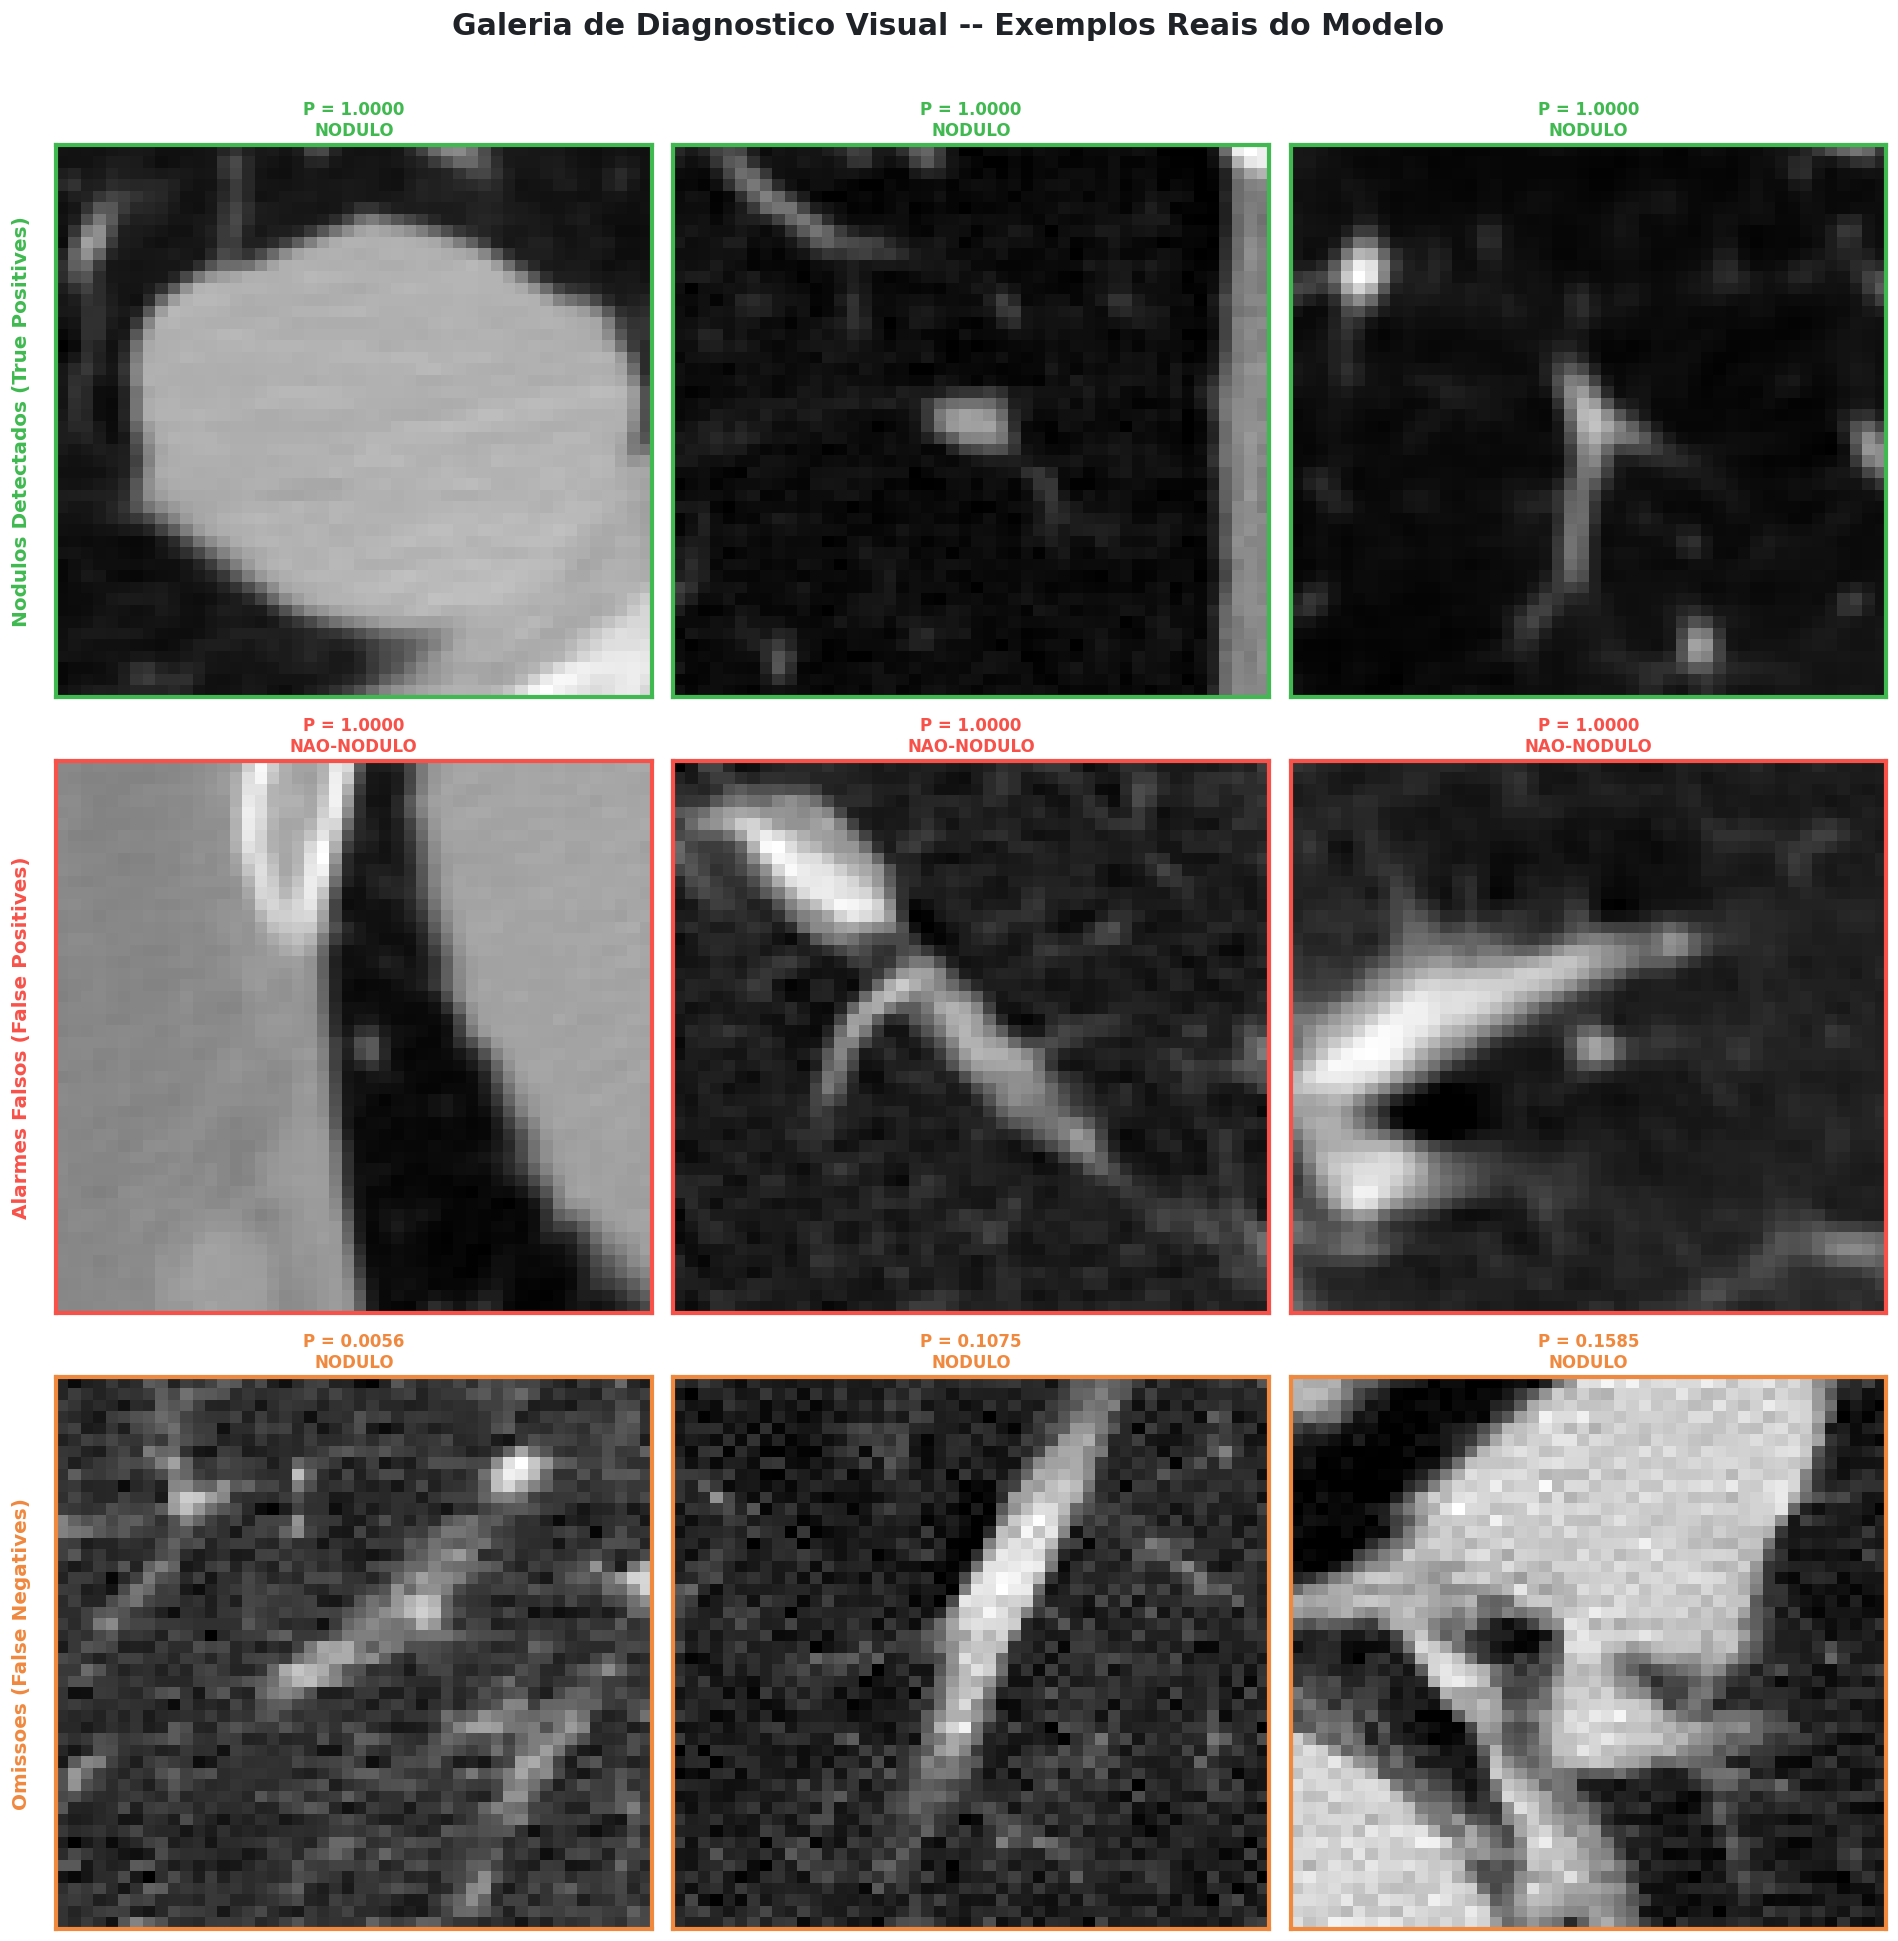

In [6]:
# ============================================================
# Galeria de Diagnostico Visual
# ============================================================
def plot_gallery(examples, title, color, ax_row):
    """Plota uma linha de crops com estilo premium."""
    for idx, (ax, ex) in enumerate(zip(ax_row, examples)):
        ct = get_ct(ex["uid"])
        crop, _ = ct.extract_crop(ex["xyz"])
        center_slice = crop[crop.shape[0]//2]
        
        ax.imshow(center_slice, cmap="gray", aspect="auto")
        
        # Borda colorida
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2.5)
        
        prob_text = f"P = {ex['prob']:.4f}"
        label_text = "NODULO" if ex["label"] == 1 else "NAO-NODULO"
        ax.set_title(f"{prob_text}\n{label_text}",
                     fontsize=10, color=color, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
        get_ct.cache_clear()

# Exemplos verificados (CTs disponiveis no disco)
tps = [
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886",
     "xyz": (67.61451718, 85.02525992, -109.8084416), "prob": 1.0000, "label": 1},
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.246758220302211646532176593724",
     "xyz": (102.42, 65.3, 1562.32), "prob": 1.0000, "label": 1},
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.986011151772797848993829243183",
     "xyz": (45.13, 84.05, -211.55), "prob": 1.0000, "label": 1}
]
fps = [
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.161002239822118346732951898613",
     "xyz": (-121.828333494, 18.933116703, -280.116923295), "prob": 1.0000, "label": 0},
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.324290109423920971676288828329",
     "xyz": (103.725866116, -120.844854799, -197.90130835), "prob": 1.0000, "label": 0},
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.199171741859530285887752432478",
     "xyz": (115.364846498, 157.926101981, -565.796715546), "prob": 1.0000, "label": 0}
]
fns = [
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.701514276942509393419164159551",
     "xyz": (-85.63, 29.12, -162.49), "prob": 0.0056, "label": 1},
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.674809958213117379592437424616",
     "xyz": (-74.7508318473, 57.6862016943, -175.315789672), "prob": 0.1075, "label": 1},
    {"uid": "1.3.6.1.4.1.14519.5.2.1.6279.6001.802595762867498341201607992711",
     "xyz": (39.99, 34.27, -171.69), "prob": 0.1585, "label": 1}
]

fig, axes = plt.subplots(3, 3, figsize=(16, 16))

row_labels = [
    ("Nodulos Detectados (True Positives)", "#3fb950"),
    ("Alarmes Falsos (False Positives)", "#f85149"),
    ("Omissoes (False Negatives)", "#f0883e"),
]
examples_list = [tps, fps, fns]

for row_idx, (title, color) in enumerate(row_labels):
    plot_gallery(examples_list[row_idx], title, color, axes[row_idx])
    axes[row_idx][0].set_ylabel(title, fontsize=12, fontweight="bold",
                                color=color, labelpad=15)

plt.suptitle("Galeria de Diagnostico Visual -- Exemplos Reais do Modelo",
             fontsize=18, fontweight="bold", color="#1f2328", y=1.01)
plt.tight_layout()
plt.show()


---
## 6. Distribuicao de Probabilidades

Como o modelo distribui as probabilidades entre nodulos e nao-nodulos?
Uma boa separacao indica que o modelo aprendeu a distinguir as duas classes.


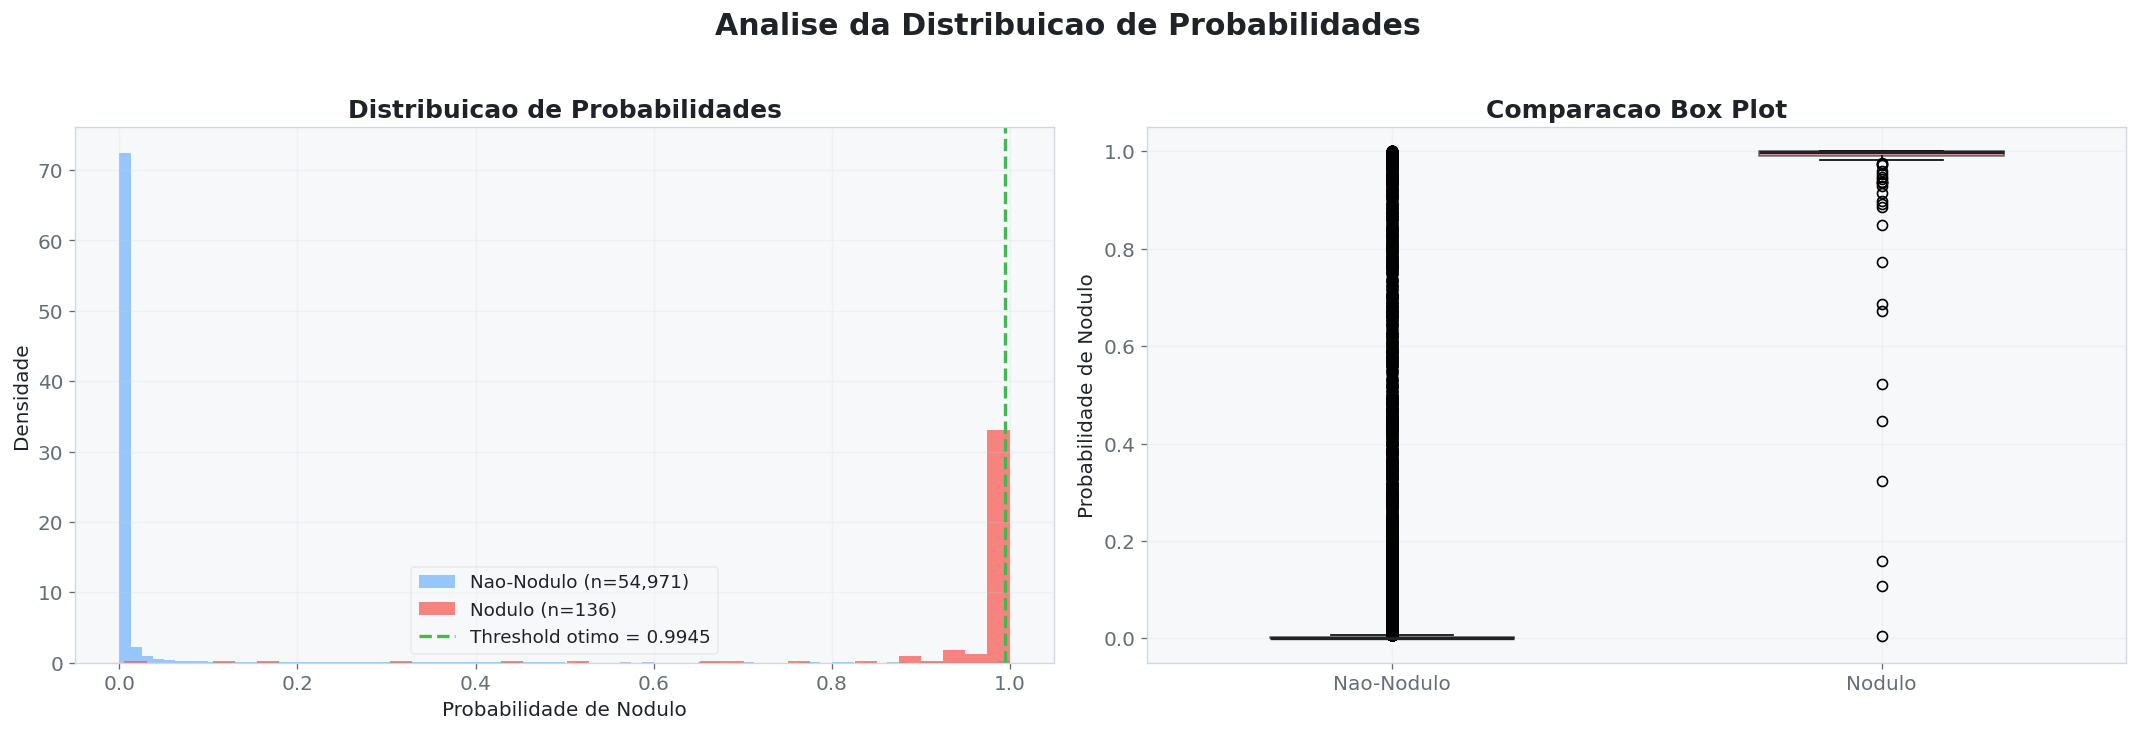

In [7]:
# ============================================================
# Distribuicao de Probabilidades
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

pos_probs = probs[labels == 1]
neg_probs = probs[labels == 0]

# Histograma sobreposto
ax1.hist(neg_probs, bins=80, alpha=0.6, color="#58a6ff", label=f"Nao-Nodulo (n={len(neg_probs):,})",
         edgecolor="none", density=True)
ax1.hist(pos_probs, bins=40, alpha=0.7, color="#f85149", label=f"Nodulo (n={len(pos_probs):,})",
         edgecolor="none", density=True)
ax1.axvline(x=best_threshold, color="#3fb950", linestyle="--", lw=2,
             label=f"Threshold otimo = {best_threshold:.4f}")
ax1.set_xlabel("Probabilidade de Nodulo", fontsize=12)
ax1.set_ylabel("Densidade", fontsize=12)
ax1.set_title("Distribuicao de Probabilidades", fontsize=15,
               fontweight="bold", color="#1f2328")
ax1.legend(fontsize=11, framealpha=0.3)
ax1.grid(True, alpha=0.2)

# Box plot
bp = ax2.boxplot([neg_probs, pos_probs],
                  labels=["Nao-Nodulo", "Nodulo"],
                  patch_artist=True, widths=0.5,
                  medianprops=dict(color="#1f2328", linewidth=2))
bp["boxes"][0].set_facecolor("#58a6ff")
bp["boxes"][0].set_alpha(0.5)
bp["boxes"][1].set_facecolor("#f85149")
bp["boxes"][1].set_alpha(0.5)
ax2.set_ylabel("Probabilidade de Nodulo", fontsize=12)
ax2.set_title("Comparacao Box Plot", fontsize=15,
               fontweight="bold", color="#1f2328")
ax2.grid(True, alpha=0.2)

plt.suptitle("Analise da Distribuicao de Probabilidades",
             fontsize=18, fontweight="bold", color="#1f2328", y=1.02)
plt.tight_layout()
plt.show()


---
## 7. Desafios e Estrategias Futuras

### Diferenciais Tecnicos Implementados

| # | Tecnica | Descricao |
|:---:|:---|:---|
| 1 | **Robust Cache Recovery** | Sistema de carregamento resiliente que detecta e regenera automaticamente arquivos de cache corrompidos |
| 2 | **Balanced Training** | Amostragem balanceada (`ratio_int=2`) para compensar o desbalanceamento extremo (apenas 0.25% dos candidatos sao nodulos) |
| 3 | **3D Data Augmentation** | Flip, offset, scale, rotacao e ruido aplicados via transformacao afim (`affine_grid` + `grid_sample`) |
| 4 | **Two-Phase Training** | Learning rate decay entre Fase 1 e Fase 2 para fine-tuning |

---

### Analise dos Erros

| Tipo de Erro | Causa Provavel | Estrategia de Melhoria |
|:---|:---|:---|
| **Falsos Positivos** | Vasos sanguineos em corte transversal | Aumentar profundidade do crop; augmentations mais agressivas |
| **Falsos Negativos** | Nodulos muito pequenos ou colados na parede | Focal Loss para exemplos dificeis |
| **Precision baixa** | Desbalanceamento extremo do dataset | Ajustar `ratio_int`; tecnicas de hard negative mining |

---

### Proximos Passos

- [ ] Implementar **Focal Loss** para focar em exemplos dificeis
- [ ] Experimentar **ratio_int=3 ou 4** no balanceamento
- [ ] Testar **learning rate schedulers** (cosine annealing)
- [ ] Adicionar **dropout** para regularizacao
- [ ] Avaliar **segmentacao** para localizar nodulos no CT completo

---

**Projeto**: Lung Cancer Detection -- LUNA16 | **Stack**: Python - PyTorch - SimpleITK - scikit-learn - Matplotlib | **Dataset**: [LUNA16 Grand Challenge](https://luna16.grand-challenge.org/)
